In [2]:
%pip install scikit-learn xgboost
%pip install \
    --extra-index-url=https://pypi.nvidia.com \
    "cudf-cu13==26.6.*" "dask-cudf-cu13==26.6.*" "cuml-cu13==26.6.*" \
    "cugraph-cu13==26.6.*" "nx-cugraph-cu13==26.6.*" "cuxfilter-cu13==26.6.*" \
    "cucim-cu13==26.6.*" "pylibraft-cu13==26.6.*" "raft-dask-cu13==26.6.*" \
    "cuvs-cu13==26.6.*" "nvforest-cu13==26.6.*" "nx-cugraph-cu13==26.6.*"
%pip install imblearn

Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [imblearn]
Note: you may need to restart the kernel to use updated packages.


In [40]:
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score
from sklearn.svm import SVC
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import numpy as np
random_seed = 2026
np.random.seed(random_seed)

### The Plan
- Split trainval and test grouped by subject_ID (to prevent data leakage); stratify mind wandering
- KFold cross validation using trainval during hyperparameter gridsearch (I will try to prevent data leakage here as well); stratify mind wandering

## Load Data

In [67]:
# Load data
path = "data/preprocessed/data_channels_2000ms.pkl"
data = pd.read_pickle(path).reset_index(drop=True)
display(data.head())

# Split data
data_all = data.copy()
data = data[data["subject"]=="s10014"]
groups = data["subject"]
X = data[[*data.columns][2:]].astype(float)
y = data["is_mw"].astype(int)
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=random_seed)
cv = StratifiedKFold(n_splits=5, shuffle=False)

,subject,is_mw,delta_Fp1,delta_AF7,delta_AF3,delta_F1,delta_F3,delta_F5,delta_F7,delta_FT7,...,gamma_CP4,gamma_CP2,gamma_P2,gamma_P4,gamma_P6,gamma_P8,gamma_P10,gamma_PO8,gamma_PO4,gamma_O2
0,s10014,0.0,0.002296,0.863017,0.410482,0.467975,0.776714,0.568553,1.923164,1.021138,...,-0.522969,-0.272734,-1.232738,-0.494328,-0.044546,0.209405,0.963543,0.459678,-0.163325,-0.022170
1,s10014,0.0,-0.165193,0.482863,-0.084404,-0.445854,-0.027316,0.565583,1.297329,0.800956,...,-0.403381,-0.577911,0.378159,-0.121743,-0.330614,0.025925,0.382041,-0.204938,-0.020287,-0.520880
2,s10014,0.0,-0.929301,-0.042521,-0.481090,0.565159,1.451261,0.413914,0.849775,0.726644,...,-0.634446,-0.799034,0.909853,-0.436787,-0.036893,0.389724,0.427821,-0.235369,-0.037275,-0.561163
3,s10014,0.0,-0.676932,0.214686,-0.547385,-0.605933,-0.646305,-0.321214,0.360004,0.427207,...,-0.531509,-0.555484,-0.300942,-0.160862,0.194674,0.487393,1.471904,0.549606,-0.060861,-0.004922
4,s10014,0.0,-0.325974,-0.812253,-0.390728,-0.061498,0.102450,-0.220585,0.243879,0.385748,...,-0.929872,-0.834784,-0.731715,-0.817120,-0.534581,0.249960,1.644982,0.129897,-0.173109,-0.002645


## Training
### Logistic Regression

In [55]:
def train_logistic_regression(X, y, groups, parameters):
    cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=random_seed)
    cv = StratifiedKFold(n_splits=4, shuffle=False)

    lr = LogisticRegression(l1_ratio=1, random_state=random_seed)
    clf = GridSearchCV(lr, parameters, cv=cv, scoring="roc_auc") 

    clf.fit(X,y)
    
    return clf

### SVM with radial basis function

In [56]:
def train_svc(X, y, groups, parameters):
    cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=random_seed)
    cv = StratifiedKFold(n_splits=4, shuffle=False)

    svc = SVC(probability = True,random_state=random_seed)
    clf = GridSearchCV(svc, parameters, cv=cv, scoring="roc_auc") 

    clf.fit(X,y)
    
    return clf

### XGBoost

In [57]:
def train_xgboost(X, y, groups, parameters):
    cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=random_seed)
    cv = StratifiedKFold(n_splits=4, shuffle=False)

    xgb = XGBClassifier(scale_pos_weight=len(y_trainval[y_trainval==0])/len(y_trainval[y_trainval==1]), reg_alpha = 0.1, random_state=random_seed, eval_metric="auc")
    clf = GridSearchCV(xgb, parameters, cv=cv, scoring="roc_auc") 

    clf.fit(X,y)
    
    return clf

### Training

In [58]:
lr_params = { # Why these?
    'C': [0.01, 0.1, 1],#, 10, 100], 
    'class_weight': ["balanced"],
    'solver': ["liblinear"],
    'max_iter': [1500],#,1250],
    'warm_start': [True]#, False]
}

svm_params = { # Why these?
    'C': [0.01, 0.1, 1],
    'gamma': ["auto"],#,"scale", 0.01, 0.1],
    'kernel': ["rbf", "sigmoid", "poly"]#,
    # 'degree': []
}

xgb_params = { # Why these?
    'learning_rate': [0.01],#, 0.1],
    'n_estimators': [100],#, 200],
    'max_depth': [5],#, 10],
    'reg_alpha': [25],#, 5]
}

In [42]:

for fold, (train_idxs, test_idxs) in enumerate(cv.split(X, y, groups)):
    X_trainval, y_trainval = X.iloc[train_idxs].reset_index(drop=True), y[train_idxs].reset_index(drop=True)
    X_test, y_test = X.iloc[test_idxs].reset_index(drop=True), y[test_idxs].reset_index(drop=True)
    groups_train = groups[train_idxs]
    groups_test = groups[test_idxs]

    print(f"Fold {fold}")
    best_logreg_clf = train_logistic_regression(X_trainval, y_trainval, groups_train, parameters=lr_params)
    perf_auc = roc_auc_score(y_test, best_logreg_clf.predict_proba(X_test)[:,1])
    print(f"ROC-AUC (LogisticRegression({best_logreg_clf.best_params_})): {perf_auc}")

    best_svm_clf = train_svc(X_trainval, y_trainval, groups_train, parameters=svm_params)
    perf_auc = roc_auc_score(y_test, best_svm_clf.decision_function(X_test))
    print(f"ROC-AUC (SVC({best_svm_clf.best_params_})): {perf_auc}")

    best_xgb_clf = train_xgboost(X_trainval, y_trainval, groups_train, parameters=xgb_params)
    perf_auc = roc_auc_score(y_test, best_xgb_clf.predict_proba(X_test)[:,1])
    print(f"ROC-AUC (XGBoost({best_xgb_clf.best_params_})): {perf_auc}")
    # print()
    # print("Fold :", fold)
    # print("TRAIN POSITIVE RATIO:", y[train_idxs].mean())
    # print("TEST POSITIVE RATIO :", y[test_idxs].mean())
    # print(f"TRAIN PERCENTAGE    : {len(train_idxs) / len(X) * 100:.4}%")
    # print("TRAIN GROUPS        :", set(groups[train_idxs]))
    # print("TEST GROUPS         :", set(groups[test_idxs]))


Fold 0
ROC-AUC (LogisticRegression({'C': 1, 'class_weight': 'balanced', 'max_iter': 750, 'solver': 'liblinear', 'warm_start': True})): 0.5
ROC-AUC (SVC({'C': 1, 'gamma': 'auto'})): 0.5
ROC-AUC (XGBoost({'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'reg_alpha': 1})): 0.5341927605354715
Fold 1
ROC-AUC (LogisticRegression({'C': 1, 'class_weight': 'balanced', 'max_iter': 750, 'solver': 'liblinear', 'warm_start': True})): 0.5
ROC-AUC (SVC({'C': 1, 'gamma': 'auto'})): 0.5
ROC-AUC (XGBoost({'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'reg_alpha': 1})): 0.49597461362167244
Fold 2
ROC-AUC (LogisticRegression({'C': 1, 'class_weight': 'balanced', 'max_iter': 750, 'solver': 'liblinear', 'warm_start': True})): 0.5
ROC-AUC (SVC({'C': 1, 'gamma': 'auto'})): 0.5
ROC-AUC (XGBoost({'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'reg_alpha': 1})): 0.43795765172438217
Fold 3
ROC-AUC (LogisticRegression({'C': 1, 'class_weight': 'balanced', 'max_iter': 750, 'solve

In [64]:
#with smote

logreg_aucs = []
logreg_best_params = None
svc_aucs = []
svc_best_params = None
xgb_aucs = []
xgb_best_params = None

for fold, (train_idxs, test_idxs) in enumerate(cv.split(X, y)):
    X_trainval, y_trainval = X.iloc[train_idxs].reset_index(drop=True), y[train_idxs].reset_index(drop=True)
    X_test, y_test = X.iloc[test_idxs].reset_index(drop=True), y[test_idxs].reset_index(drop=True)
    smote = SMOTE(sampling_strategy='minority', random_state=random_seed)
    X_trainval_sm, y_trainval_sm = smote.fit_resample(X_trainval, y_trainval)
    groups_train = groups[train_idxs]
    groups_test = groups[test_idxs]
    rest = len(X_trainval_sm) - len(X_trainval)
    groups_train = pd.concat([groups_train, pd.Series(np.random.choice(groups_train.unique(), size = rest))])

    print(f"Fold {fold}")
    best_logreg_clf = train_logistic_regression(X_trainval_sm, y_trainval_sm, groups_train, parameters=lr_params)
    logreg_clf = best_logreg_clf.best_estimator_.fit(X_trainval_sm, y_trainval_sm)
    perf_auc = roc_auc_score(y_test, logreg_clf.predict_proba(X_test)[:,1])
    logreg_aucs.append(perf_auc)
    if perf_auc == max(logreg_aucs):
        logreg_best_params = logreg_clf.get_params()
    print(f"ROC-AUC (LogisticRegression({best_logreg_clf.best_params_})): {perf_auc} ({best_logreg_clf.best_score_})")

    best_svm_clf = train_svc(X_trainval_sm, y_trainval_sm, groups_train, parameters=svm_params)
    svm_clf = best_svm_clf.best_estimator_.fit(X_trainval_sm, y_trainval_sm)
    perf_auc = roc_auc_score(y_test, svm_clf.decision_function(X_test))
    svc_aucs.append(perf_auc)
    if perf_auc == max(svc_aucs):
        svc_best_params = svm_clf.get_params()
    print(f"ROC-AUC (SVC({best_svm_clf.best_params_})): {perf_auc} ({best_svm_clf.best_score_})")

    best_xgb_clf = train_xgboost(X_trainval_sm, y_trainval_sm, groups_train, parameters=xgb_params)
    xgb_clf = best_xgb_clf.best_estimator_.fit(X_trainval_sm, y_trainval_sm)
    perf_auc = roc_auc_score(y_test, xgb_clf.predict_proba(X_test)[:,1])
    xgb_aucs.append(perf_auc)
    if perf_auc == max(xgb_aucs):
        xgb_best_params = xgb_clf.get_params()
    print(f"ROC-AUC (XGBoost({best_xgb_clf.best_params_})): {perf_auc}  ({best_xgb_clf.best_score_})")
    # print()
    # print("Fold :", fold)
    # print("TRAIN POSITIVE RATIO:", y_trainval_sm.mean())
    # print("TEST POSITIVE RATIO :", y[test_idxs].mean())
    # print(f"TRAIN PERCENTAGE    : {len(train_idxs) / len(X) * 100:.4}%")
    # print("TRAIN GROUPS        :", set(groups[train_idxs]))
    # print("TEST GROUPS         :", set(groups[test_idxs]))

print(f"Mean Logistic Regression AUC =", sum(logreg_aucs)/len(logreg_aucs))
print(f"Mean SVC AUC =", sum(svc_aucs)/len(svc_aucs))
print(f"Mean XGBoost AUC =", sum(xgb_aucs)/len(xgb_aucs))

Fold 0
ROC-AUC (LogisticRegression({'C': 1, 'class_weight': 'balanced', 'max_iter': 1500, 'solver': 'liblinear', 'warm_start': True})): 0.5265306122448979 (0.7750292273355299)


/home/stefan/Documents/GitHub/BCI-Mind-Wandering/.conda/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/stefan/Documents/GitHub/BCI-Mind-Wandering/.conda/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/stefan/Documents/GitHub/BCI-Mind-Wandering/.conda/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/stefan/Documents/GitHub/BCI-Mind-Wandering/

ROC-AUC (SVC({'C': 1, 'gamma': 'auto', 'kernel': 'rbf'})): 0.616326530612245 (0.9993888829843767)
ROC-AUC (XGBoost({'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'reg_alpha': 25})): 0.3306122448979592  (0.8281166967796789)
Fold 1
ROC-AUC (LogisticRegression({'C': 1, 'class_weight': 'balanced', 'max_iter': 1500, 'solver': 'liblinear', 'warm_start': True})): 0.5932521087160263 (0.6776655980704536)


/home/stefan/Documents/GitHub/BCI-Mind-Wandering/.conda/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/stefan/Documents/GitHub/BCI-Mind-Wandering/.conda/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/stefan/Documents/GitHub/BCI-Mind-Wandering/.conda/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/stefan/Documents/GitHub/BCI-Mind-Wandering/

ROC-AUC (SVC({'C': 1, 'gamma': 'auto', 'kernel': 'rbf'})): 0.6850984067478914 (0.9981953882626491)
ROC-AUC (XGBoost({'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'reg_alpha': 25})): 0.4864104967197751  (0.7662124952010776)
Fold 2
ROC-AUC (LogisticRegression({'C': 1, 'class_weight': 'balanced', 'max_iter': 1500, 'solver': 'liblinear', 'warm_start': True})): 0.6316776007497658 (0.7158419750087301)


...

ROC-AUC (SVC({'C': 1, 'gamma': 'auto', 'kernel': 'rbf'})): 0.6138706654170571 (0.9992874820243753)
ROC-AUC (XGBoost({'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'reg_alpha': 25})): 0.6597938144329898  (0.7988894968126479)
Fold 3
ROC-AUC (LogisticRegression({'C': 1, 'class_weight': 'balanced', 'max_iter': 1500, 'solver': 'liblinear', 'warm_start': True})): 0.4461105904404874 (0.8305416438017443)


/home/stefan/Documents/GitHub/BCI-Mind-Wandering/.conda/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/stefan/Documents/GitHub/BCI-Mind-Wandering/.conda/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/stefan/Documents/GitHub/BCI-Mind-Wandering/.conda/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/stefan/Documents/GitHub/BCI-Mind-Wandering/

ROC-AUC (SVC({'C': 1, 'gamma': 'auto', 'kernel': 'rbf'})): 0.5810684161199625 (0.9988943499601988)
ROC-AUC (XGBoost({'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'reg_alpha': 25})): 0.5688847235238987  (0.8138081808342426)
Fold 4
ROC-AUC (LogisticRegression({'C': 1, 'class_weight': 'balanced', 'max_iter': 1500, 'solver': 'liblinear', 'warm_start': True})): 0.6773195876288659 (0.6964475502178764)


/home/stefan/Documents/GitHub/BCI-Mind-Wandering/.conda/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/stefan/Documents/GitHub/BCI-Mind-Wandering/.conda/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/stefan/Documents/GitHub/BCI-Mind-Wandering/.conda/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/stefan/Documents/GitHub/BCI-Mind-Wandering/

ROC-AUC (SVC({'C': 1, 'gamma': 'auto', 'kernel': 'rbf'})): 0.5855670103092784 (0.9972778993625295)
ROC-AUC (XGBoost({'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'reg_alpha': 25})): 0.6123711340206186  (0.8055031981971236)
Mean Logistic Regression AUC = 0.5749780999560087
Mean SVC AUC = 0.6163862058412869
Mean XGBoost AUC = 0.5316144827190483


In [66]:
print(f"Mean Logistic Regression  AUC = {sum(logreg_aucs)/len(logreg_aucs)} ({logreg_best_params})") 
print(f"Mean SVC AUC = {sum(svc_aucs)/len(svc_aucs)} ({svc_best_params})")
print(f"Mean XGBoost AUC = {sum(xgb_aucs)/len(xgb_aucs)} ({xgb_best_params})")

Mean Logistic Regression  AUC = 0.5749780999560087 ({'C': 1, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 1, 'max_iter': 1500, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': 2026, 'solver': 'liblinear', 'tol': 0.0001, 'verbose': 0, 'warm_start': True})
Mean SVC AUC = 0.6163862058412869 ({'C': 1, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'auto', 'kernel': 'rbf', 'max_iter': -1, 'probability': True, 'random_state': 2026, 'shrinking': True, 'tol': 0.001, 'verbose': False})
Mean XGBoost AUC = 0.5316144827190483 ({'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'auc', 'feature_types': None, 'feature_weights': None, 'gamma': None, 

In [71]:
data_all["subject"].value_counts()

subject
s10084    675
s10052    650
s10085    648
s10081    592
s10014    539
Name: count, dtype: int64

In [70]:
for subject_id in data_all["subject"].unique():
    print(subject_id)

s10014
s10081
s10085
s10084
s10052


<Axes: >

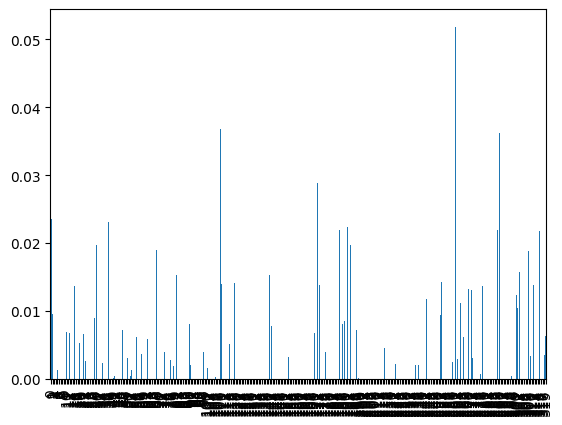

In [61]:
pd.Series(xgb_clf.feature_importances_).plot.bar()